In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from IPython.display import display
from tqdm.auto import tqdm

from tokenizer import DigitTokenizer
from data_stream import MultiplicationDataStream
from combined_modular_arithmetic_model import (
    CombinedModularArithmeticModel,
)

In [2]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

batch_size = 100

max_seq_len = 32
max_modulus = 20

d_model = 256
dropout = 0.1

learning_rate = 1e-4
weight_decay = 0.1

product_loss_weight = 1.0
cell_loss_weight = 0.5
carry_loss_weight = 0.5
final_remainder_loss_weight = 1.0
intermediate_remainder_loss_weight = 1.0

validation_interval = 100
validation_steps = 20
plot_interval = 10

use_bf16 = (
    device.type == "cuda"
    and torch.cuda.is_bf16_supported()
)

torch.set_float32_matmul_precision(
    "high"
)

print("Device:", device)
print("BF16:", use_bf16)

Device: cuda
BF16: True


In [3]:
tokenizer = DigitTokenizer()

data_stream = MultiplicationDataStream(
    tokenizer=tokenizer,
    batch_size=batch_size,
    max_seq_len=max_seq_len,
    initial_max=max_modulus,
    growth_rate=0.0,
    beta_alpha=2.0,
    beta_beta=5.0,
    max_operand_multiple=3,
    rehearsal_fraction=0.0,
    rehearsal_max=max_modulus,
    seed=42,
)

pad_id = tokenizer.char_to_int[
    "<pad>"
]

eos_id = tokenizer.char_to_int[
    "<eos>"
]

In [4]:
model = CombinedModularArithmeticModel(
    vocab_size=tokenizer.vocab_size,
    max_seq_len=max_seq_len,
    max_modulus=max_modulus,
    pad_id=pad_id,
    eos_id=eos_id,
    d_model=d_model,
    dropout=dropout,
).to(
    device
)

parameter_count = sum(
    parameter.numel()
    for parameter in model.parameters()
)

multiplication_parameter_count = sum(
    parameter.numel()
    for parameter
    in model.multiplication_model.parameters()
)

modulo_parameter_count = sum(
    parameter.numel()
    for parameter
    in model.modulo_model.parameters()
)

print(
    f"Total parameters: {parameter_count:,}"
)

print(
    f"Multiplication parameters: "
    f"{multiplication_parameter_count:,}"
)

print(
    f"Modulo parameters: "
    f"{modulo_parameter_count:,}"
)

Total parameters: 2,000,505
Multiplication parameters: 1,373,797
Modulo parameters: 626,708


In [5]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=learning_rate,
    weight_decay=weight_decay,
)

product_loss_function = nn.CrossEntropyLoss(
    ignore_index=pad_id
)

cell_loss_function = nn.CrossEntropyLoss(
    ignore_index=-100
)

carry_loss_function = nn.CrossEntropyLoss(
    ignore_index=-100
)

final_remainder_loss_function = (
    nn.CrossEntropyLoss()
)

intermediate_remainder_loss_function = (
    nn.CrossEntropyLoss(
        ignore_index=-100
    )
)

In [6]:
def reversed_digits_to_integers(
    digits: torch.Tensor,
) -> torch.Tensor:
    _, seq_len = digits.shape

    digit_mask = (
        (digits >= 0)
        & (digits <= 9)
    )

    numeric_digits = digits.masked_fill(
        ~digit_mask,
        0,
    )

    powers = (
        10
        ** torch.arange(
            seq_len,
            device=digits.device,
            dtype=torch.long,
        )
    )

    values = (
        numeric_digits
        * powers.unsqueeze(0)
    ).sum(
        dim=1
    )

    return values

In [7]:
def create_product_targets(
    a: torch.Tensor,
    b: torch.Tensor,
) -> torch.Tensor:
    a_values = reversed_digits_to_integers(
        a
    )

    b_values = reversed_digits_to_integers(
        b
    )

    product_values = (
        a_values
        * b_values
    )

    batch_size = a.shape[0]

    product_targets = torch.full(
        (
            batch_size,
            model.multiplication_model.product_seq_len,
        ),
        pad_id,
        dtype=torch.long,
        device=a.device,
    )

    for batch_index in range(
        batch_size
    ):
        product_digits = [
            int(digit)
            for digit in reversed(
                str(
                    product_values[
                        batch_index
                    ].item()
                )
            )
        ]

        product_tokens = (
            product_digits
            + [eos_id]
        )

        if (
            len(product_tokens)
            > model.multiplication_model.product_seq_len
        ):
            raise ValueError(
                "Product target exceeds product sequence length."
            )

        product_targets[
            batch_index,
            :len(product_tokens),
        ] = torch.tensor(
            product_tokens,
            dtype=torch.long,
            device=a.device,
        )

    return product_targets

In [8]:
def create_cell_targets(
    a: torch.Tensor,
    b: torch.Tensor,
) -> tuple[
    torch.Tensor,
    torch.Tensor,
]:
    digit_a = a.unsqueeze(
        dim=2
    )

    digit_b = b.unsqueeze(
        dim=1
    )

    valid_cells = (
        (digit_a >= 0)
        & (digit_a <= 9)
        & (digit_b >= 0)
        & (digit_b <= 9)
    )

    digit_products = (
        digit_a.clamp(
            min=0,
            max=9,
        )
        * digit_b.clamp(
            min=0,
            max=9,
        )
    )

    ones_targets = (
        digit_products % 10
    )

    tens_targets = (
        digit_products // 10
    )

    ones_targets = ones_targets.masked_fill(
        ~valid_cells,
        -100,
    )

    tens_targets = tens_targets.masked_fill(
        ~valid_cells,
        -100,
    )

    return (
        ones_targets,
        tens_targets,
    )

In [9]:
def create_carry_targets(
    a: torch.Tensor,
    b: torch.Tensor,
) -> torch.Tensor:
    batch_size = a.shape[0]

    carry_targets = torch.full(
        (
            batch_size,
            model.multiplication_model.product_seq_len,
        ),
        -100,
        dtype=torch.long,
        device=a.device,
    )

    a_values = reversed_digits_to_integers(
        a
    )

    b_values = reversed_digits_to_integers(
        b
    )

    for batch_index in range(
        batch_size
    ):
        a_digits = a[
            batch_index
        ][
            (a[batch_index] >= 0)
            & (a[batch_index] <= 9)
        ].tolist()

        b_digits = b[
            batch_index
        ][
            (b[batch_index] >= 0)
            & (b[batch_index] <= 9)
        ].tolist()

        product_value = (
            a_values[batch_index]
            * b_values[batch_index]
        ).item()

        product_digit_count = len(
            str(product_value)
        )

        diagonal_sums = [
            0
        ] * product_digit_count

        for a_position, a_digit in enumerate(
            a_digits
        ):
            for b_position, b_digit in enumerate(
                b_digits
            ):
                diagonal_position = (
                    a_position
                    + b_position
                )

                if (
                    diagonal_position
                    < product_digit_count
                ):
                    diagonal_sums[
                        diagonal_position
                    ] += (
                        a_digit
                        * b_digit
                    )

        carry = 0

        for position in range(
            product_digit_count
        ):
            total = (
                diagonal_sums[position]
                + carry
            )

            carry = total // 10

            carry_targets[
                batch_index,
                position,
            ] = carry

    return carry_targets

In [10]:
def create_ground_truth_product_inputs(
    a: torch.Tensor,
    b: torch.Tensor,
) -> tuple[
    torch.Tensor,
    torch.Tensor,
]:
    a_values = reversed_digits_to_integers(
        a
    )

    b_values = reversed_digits_to_integers(
        b
    )

    product_values = (
        a_values
        * b_values
    )

    batch_size = a.shape[0]

    product_inputs = torch.full(
        (
            batch_size,
            model.max_product_seq_len,
        ),
        pad_id,
        dtype=torch.long,
        device=a.device,
    )

    for batch_index in range(
        batch_size
    ):
        product_digits = [
            int(digit)
            for digit in str(
                product_values[
                    batch_index
                ].item()
            )
        ]

        if (
            len(product_digits)
            > model.max_product_seq_len
        ):
            raise ValueError(
                "Product exceeds maximum modulo input length."
            )

        product_inputs[
            batch_index,
            :len(product_digits),
        ] = torch.tensor(
            product_digits,
            dtype=torch.long,
            device=a.device,
        )

    product_padding_mask = (
        product_inputs == pad_id
    )

    return (
        product_inputs,
        product_padding_mask,
    )

In [11]:
def create_modulus_values(
    p: torch.Tensor,
) -> torch.Tensor:
    modulus_values = (
        reversed_digits_to_integers(
            p
        )
    )

    if torch.any(
        modulus_values < 1
    ):
        raise ValueError(
            "Modulus must be at least 1."
        )

    if torch.any(
        modulus_values > max_modulus
    ):
        raise ValueError(
            f"Modulus exceeds max_modulus={max_modulus}."
        )

    return modulus_values

def create_remainder_targets(
    product_inputs: torch.Tensor,
    product_padding_mask: torch.Tensor,
    modulus_values: torch.Tensor,
) -> tuple[
    torch.Tensor,
    torch.Tensor,
]:
    batch_size = (
        product_inputs.shape[0]
    )

    final_targets = torch.zeros(
        batch_size,
        dtype=torch.long,
        device=product_inputs.device,
    )

    intermediate_targets = torch.full(
        (
            batch_size,
            model.max_product_seq_len,
        ),
        -100,
        dtype=torch.long,
        device=product_inputs.device,
    )

    remainders = torch.zeros(
        batch_size,
        dtype=torch.long,
        device=product_inputs.device,
    )

    for step in range(
        model.max_product_seq_len
    ):
        active_step = (
            ~product_padding_mask[
                :,
                step,
            ]
        )

        current_digits = product_inputs[
            :,
            step,
        ].masked_fill(
            ~active_step,
            0,
        )

        updated_remainders = (
            10 * remainders
            + current_digits
        ) % modulus_values

        remainders = torch.where(
            active_step,
            updated_remainders,
            remainders,
        )

        intermediate_targets[
            active_step,
            step,
        ] = remainders[
            active_step
        ]

    final_targets.copy_(
        remainders
    )

    return (
        final_targets,
        intermediate_targets,
    )

In [12]:
def truncate_predictions_after_eos(
    predictions: torch.Tensor,
) -> torch.Tensor:
    _, seq_len = predictions.shape

    positions = torch.arange(
        seq_len,
        device=predictions.device,
    ).unsqueeze(0)

    eos_mask = (
        predictions == eos_id
    )

    has_eos = eos_mask.any(
        dim=1
    )

    eos_positions = eos_mask.int().argmax(
        dim=1
    )

    after_eos = (
        positions
        > eos_positions.unsqueeze(1)
    )

    after_eos = (
        after_eos
        & has_eos.unsqueeze(1)
    )

    return predictions.masked_fill(
        after_eos,
        pad_id,
    )


def compute_product_exact_accuracy(
    product_logits: torch.Tensor,
    product_targets: torch.Tensor,
) -> tuple[int, int]:
    predictions = product_logits.argmax(
        dim=-1
    )

    predictions = (
        truncate_predictions_after_eos(
            predictions
        )
    )

    correct_tokens = (
        (predictions == product_targets)
        | (product_targets == pad_id)
    )

    correct_sequences = (
        correct_tokens.all(
            dim=1
        )
    )

    return (
        correct_sequences.sum().item(),
        product_targets.shape[0],
    )


def compute_masked_accuracy(
    logits: torch.Tensor,
    targets: torch.Tensor,
    ignore_index: int,
) -> tuple[int, int]:
    predictions = logits.argmax(
        dim=-1
    )

    valid_positions = (
        targets != ignore_index
    )

    correct_count = (
        (
            (predictions == targets)
            & valid_positions
        )
        .sum()
        .item()
    )

    valid_count = (
        valid_positions.sum().item()
    )

    return (
        correct_count,
        valid_count,
    )


def compute_class_accuracy(
    logits: torch.Tensor,
    targets: torch.Tensor,
) -> tuple[int, int]:
    predictions = logits.argmax(
        dim=-1
    )

    correct_count = (
        predictions == targets
    ).sum().item()

    return (
        correct_count,
        targets.shape[0],
    )

In [13]:
sample_batch = data_stream.next_batch().to(
    device
)

sample_a, sample_b, sample_p, _ = (
    sample_batch.unbind(
        dim=1
    )
)

sample_product_targets = (
    create_product_targets(
        sample_a,
        sample_b,
    )
)

(
    sample_product_inputs,
    sample_product_padding_mask,
) = create_ground_truth_product_inputs(
    sample_a,
    sample_b,
)

sample_modulus_values = (
    create_modulus_values(
        sample_p
    )
)

(
    sample_final_remainder_targets,
    sample_intermediate_remainder_targets,
) = create_remainder_targets(
    sample_product_inputs,
    sample_product_padding_mask,
    sample_modulus_values,
)

sample_a_values = (
    reversed_digits_to_integers(
        sample_a
    )
)

sample_b_values = (
    reversed_digits_to_integers(
        sample_b
    )
)

for index in range(5):
    a_value = sample_a_values[
        index
    ].item()

    b_value = sample_b_values[
        index
    ].item()

    modulus = sample_modulus_values[
        index
    ].item()

    product_digits_msd = (
        sample_product_inputs[
            index
        ][
            ~sample_product_padding_mask[
                index
            ]
        ].tolist()
    )

    intermediate_remainders = (
        sample_intermediate_remainder_targets[
            index
        ]
    )

    intermediate_remainders = (
        intermediate_remainders[
            intermediate_remainders
            != -100
        ].tolist()
    )

    print(
        f"{a_value} × {b_value} = "
        f"{a_value * b_value}"
    )

    print(
        "modulus:",
        modulus,
    )

    print(
        "product digits MSD-first:",
        product_digits_msd,
    )

    print(
        "intermediate remainders:",
        intermediate_remainders,
    )

    print(
        "final remainder:",
        sample_final_remainder_targets[
            index
        ].item(),
    )

    print(
        "expected:",
        (
            a_value
            * b_value
        ) % modulus,
    )

    print()

7 × 13 = 91
modulus: 4
product digits MSD-first: [9, 1]
intermediate remainders: [1, 3]
final remainder: 3
expected: 3

51 × 68 = 3468
modulus: 19
product digits MSD-first: [3, 4, 6, 8]
intermediate remainders: [3, 15, 4, 10]
final remainder: 10
expected: 10

19 × 22 = 418
modulus: 12
product digits MSD-first: [4, 1, 8]
intermediate remainders: [4, 5, 10]
final remainder: 10
expected: 10

3 × 5 = 15
modulus: 7
product digits MSD-first: [1, 5]
intermediate remainders: [1, 1]
final remainder: 1
expected: 1

65 × 57 = 3705
modulus: 20
product digits MSD-first: [3, 7, 0, 5]
intermediate remainders: [3, 17, 10, 5]
final remainder: 5
expected: 5



In [14]:
def compute_batch_results(
    batch: torch.Tensor,
) -> dict:
    a, b, p, _ = batch.unbind(
        dim=1
    )

    product_targets = (
        create_product_targets(
            a,
            b,
        )
    )

    (
        ones_targets,
        tens_targets,
    ) = create_cell_targets(
        a,
        b,
    )

    carry_targets = (
        create_carry_targets(
            a,
            b,
        )
    )

    (
        ground_truth_product_inputs,
        ground_truth_product_padding_mask,
    ) = create_ground_truth_product_inputs(
        a,
        b,
    )

    modulus_values = (
        create_modulus_values(
            p
        )
    )

    (
        final_remainder_targets,
        intermediate_remainder_targets,
    ) = create_remainder_targets(
        ground_truth_product_inputs,
        ground_truth_product_padding_mask,
        modulus_values,
    )

    product_digit_mask = (
        (product_targets >= 0)
        & (product_targets <= 9)
    )

    (
        final_remainder_logits,
        intermediate_remainder_logits,
        product_logits,
        ones_cell_logits,
        tens_cell_logits,
        carry_logits,
    ) = model(
        a,
        b,
        modulus_values,
        product_digit_mask,
    )

    product_loss = (
        product_loss_function(
            product_logits.reshape(
                -1,
                tokenizer.vocab_size,
            ),
            product_targets.reshape(
                -1
            ),
        )
    )

    ones_loss = (
        cell_loss_function(
            ones_cell_logits.reshape(
                -1,
                10,
            ),
            ones_targets.reshape(
                -1
            ),
        )
    )

    tens_loss = (
        cell_loss_function(
            tens_cell_logits.reshape(
                -1,
                10,
            ),
            tens_targets.reshape(
                -1
            ),
        )
    )

    carry_loss = (
        carry_loss_function(
            carry_logits.reshape(
                -1,
                model.multiplication_model.carry_vocab_size,
            ),
            carry_targets.reshape(
                -1
            ),
        )
    )

    final_remainder_loss = (
        final_remainder_loss_function(
            final_remainder_logits,
            final_remainder_targets,
        )
    )

    intermediate_remainder_loss = (
        intermediate_remainder_loss_function(
            intermediate_remainder_logits.reshape(
                -1,
                model.modulo_model.remainder_class_count,
            ),
            intermediate_remainder_targets.reshape(
                -1
            ),
        )
    )

    total_loss = (
        product_loss_weight
        * product_loss
        + cell_loss_weight
        * ones_loss
        + cell_loss_weight
        * tens_loss
        + carry_loss_weight
        * carry_loss
        + final_remainder_loss_weight
        * final_remainder_loss
        + intermediate_remainder_loss_weight
        * intermediate_remainder_loss
    )

    return {
        "a": a,
        "b": b,
        "modulus_values": modulus_values,
        "product_targets": product_targets,
        "ones_targets": ones_targets,
        "tens_targets": tens_targets,
        "carry_targets": carry_targets,
        "final_remainder_targets": (
            final_remainder_targets
        ),
        "intermediate_remainder_targets": (
            intermediate_remainder_targets
        ),
        "final_remainder_logits": (
            final_remainder_logits
        ),
        "intermediate_remainder_logits": (
            intermediate_remainder_logits
        ),
        "product_logits": product_logits,
        "ones_cell_logits": ones_cell_logits,
        "tens_cell_logits": tens_cell_logits,
        "carry_logits": carry_logits,
        "total_loss": total_loss,
        "product_loss": product_loss,
        "ones_loss": ones_loss,
        "tens_loss": tens_loss,
        "carry_loss": carry_loss,
        "final_remainder_loss": (
            final_remainder_loss
        ),
        "intermediate_remainder_loss": (
            intermediate_remainder_loss
        ),
    }

In [15]:
@torch.no_grad()
def validate_model() -> dict[str, float]:
    model.eval()

    validation_loader = (
        data_stream.create_validation_chunk_loader(
            num_steps=validation_steps,
            lookahead_steps=0,
            batch_size=batch_size,
            seed=10_000,
        )
    )

    metric_sums = {
        "total_loss": 0.0,
        "product_loss": 0.0,
        "ones_loss": 0.0,
        "tens_loss": 0.0,
        "carry_loss": 0.0,
        "final_remainder_loss": 0.0,
        "intermediate_remainder_loss": 0.0,
    }

    product_exact_correct = 0
    product_exact_count = 0

    product_token_correct = 0
    product_token_count = 0

    ones_correct = 0
    ones_count = 0

    tens_correct = 0
    tens_count = 0

    carry_correct = 0
    carry_count = 0

    soft_final_correct = 0
    soft_final_count = 0

    intermediate_correct = 0
    intermediate_count = 0

    hard_final_correct = 0
    hard_final_count = 0

    total_batches = 0

    for batch in validation_loader:
        batch = batch.to(
            device
        )

        with torch.autocast(
            device_type=device.type,
            dtype=torch.bfloat16,
            enabled=use_bf16,
        ):
            results = compute_batch_results(
                batch
            )

        (
            batch_product_exact_correct,
            batch_product_exact_count,
        ) = compute_product_exact_accuracy(
            results["product_logits"],
            results["product_targets"],
        )

        (
            batch_product_token_correct,
            batch_product_token_count,
        ) = compute_masked_accuracy(
            results["product_logits"],
            results["product_targets"],
            pad_id,
        )

        (
            batch_ones_correct,
            batch_ones_count,
        ) = compute_masked_accuracy(
            results["ones_cell_logits"],
            results["ones_targets"],
            -100,
        )

        (
            batch_tens_correct,
            batch_tens_count,
        ) = compute_masked_accuracy(
            results["tens_cell_logits"],
            results["tens_targets"],
            -100,
        )

        (
            batch_carry_correct,
            batch_carry_count,
        ) = compute_masked_accuracy(
            results["carry_logits"],
            results["carry_targets"],
            -100,
        )

        (
            batch_soft_final_correct,
            batch_soft_final_count,
        ) = compute_class_accuracy(
            results["final_remainder_logits"],
            results["final_remainder_targets"],
        )

        (
            batch_intermediate_correct,
            batch_intermediate_count,
        ) = compute_masked_accuracy(
            results[
                "intermediate_remainder_logits"
            ],
            results[
                "intermediate_remainder_targets"
            ],
            -100,
        )

        (
            hard_remainder_predictions,
            _,
        ) = model.predict(
            results["a"],
            results["b"],
            results["modulus_values"],
        )

        batch_hard_final_correct = (
            hard_remainder_predictions
            == results["final_remainder_targets"]
        ).sum().item()

        batch_hard_final_count = (
            results[
                "final_remainder_targets"
            ].shape[0]
        )

        product_exact_correct += (
            batch_product_exact_correct
        )

        product_exact_count += (
            batch_product_exact_count
        )

        product_token_correct += (
            batch_product_token_correct
        )

        product_token_count += (
            batch_product_token_count
        )

        ones_correct += (
            batch_ones_correct
        )

        ones_count += (
            batch_ones_count
        )

        tens_correct += (
            batch_tens_correct
        )

        tens_count += (
            batch_tens_count
        )

        carry_correct += (
            batch_carry_correct
        )

        carry_count += (
            batch_carry_count
        )

        soft_final_correct += (
            batch_soft_final_correct
        )

        soft_final_count += (
            batch_soft_final_count
        )

        intermediate_correct += (
            batch_intermediate_correct
        )

        intermediate_count += (
            batch_intermediate_count
        )

        hard_final_correct += (
            batch_hard_final_correct
        )

        hard_final_count += (
            batch_hard_final_count
        )

        for metric_name in metric_sums:
            metric_sums[metric_name] += (
                results[metric_name].item()
            )

        total_batches += 1

    return {
        "total_loss": (
            metric_sums["total_loss"]
            / total_batches
        ),
        "product_loss": (
            metric_sums["product_loss"]
            / total_batches
        ),
        "carry_loss": (
            metric_sums["carry_loss"]
            / total_batches
        ),
        "final_remainder_loss": (
            metric_sums[
                "final_remainder_loss"
            ]
            / total_batches
        ),
        "intermediate_remainder_loss": (
            metric_sums[
                "intermediate_remainder_loss"
            ]
            / total_batches
        ),
        "product_exact_accuracy": (
            product_exact_correct
            / product_exact_count
        ),
        "product_token_accuracy": (
            product_token_correct
            / product_token_count
        ),
        "ones_accuracy": (
            ones_correct
            / ones_count
        ),
        "tens_accuracy": (
            tens_correct
            / tens_count
        ),
        "carry_accuracy": (
            carry_correct
            / carry_count
        ),
        "soft_final_remainder_accuracy": (
            soft_final_correct
            / soft_final_count
        ),
        "intermediate_remainder_accuracy": (
            intermediate_correct
            / intermediate_count
        ),
        "hard_final_remainder_accuracy": (
            hard_final_correct
            / hard_final_count
        ),
    }

In [16]:
global_step = 0

train_step_history = []

train_total_loss_history = []
train_product_loss_history = []
train_carry_loss_history = []
train_final_remainder_loss_history = []
train_intermediate_remainder_loss_history = []

train_product_exact_accuracy_history = []
train_product_token_accuracy_history = []
train_carry_accuracy_history = []
train_soft_final_remainder_accuracy_history = []
train_intermediate_remainder_accuracy_history = []

validation_step_history = []

validation_total_loss_history = []
validation_product_loss_history = []
validation_carry_loss_history = []
validation_final_remainder_loss_history = []
validation_intermediate_remainder_loss_history = []

validation_product_exact_accuracy_history = []
validation_product_token_accuracy_history = []
validation_carry_accuracy_history = []
validation_soft_final_remainder_accuracy_history = []
validation_intermediate_remainder_accuracy_history = []
validation_hard_final_remainder_accuracy_history = []

In [17]:
def train_model(
    steps: int,
) -> None:
    global global_step

    figure, axes = plt.subplots(
        3,
        1,
        figsize=(14, 14),
        sharex=True,
    )

    total_loss_axis = axes[0]
    component_loss_axis = axes[1]
    accuracy_axis = axes[2]

    display_handle = display(
        figure,
        display_id=True,
    )

    def update_live_plot() -> None:
        total_loss_axis.clear()
        component_loss_axis.clear()
        accuracy_axis.clear()

        total_loss_axis.plot(
            train_step_history,
            train_total_loss_history,
            label="Training total loss",
            linewidth=2,
        )

        if validation_total_loss_history:
            total_loss_axis.plot(
                validation_step_history,
                validation_total_loss_history,
                label="Validation total loss",
                linewidth=2,
                marker="o",
            )

        component_loss_axis.plot(
            train_step_history,
            train_product_loss_history,
            label="Training product loss",
            linewidth=2,
        )

        component_loss_axis.plot(
            train_step_history,
            train_carry_loss_history,
            label="Training carry loss",
            linewidth=2,
        )

        component_loss_axis.plot(
            train_step_history,
            train_final_remainder_loss_history,
            label="Training final remainder loss",
            linewidth=2,
        )

        component_loss_axis.plot(
            train_step_history,
            train_intermediate_remainder_loss_history,
            label="Training intermediate remainder loss",
            linewidth=2,
        )

        if validation_product_loss_history:
            component_loss_axis.plot(
                validation_step_history,
                validation_product_loss_history,
                label="Validation product loss",
                linewidth=2,
                marker="o",
            )

            component_loss_axis.plot(
                validation_step_history,
                validation_carry_loss_history,
                label="Validation carry loss",
                linewidth=2,
                marker="o",
            )

            component_loss_axis.plot(
                validation_step_history,
                validation_final_remainder_loss_history,
                label="Validation final remainder loss",
                linewidth=2,
                marker="o",
            )

            component_loss_axis.plot(
                validation_step_history,
                validation_intermediate_remainder_loss_history,
                label="Validation intermediate remainder loss",
                linewidth=2,
                marker="o",
            )

        accuracy_axis.plot(
            train_step_history,
            train_product_exact_accuracy_history,
            label="Training product exact",
            linewidth=2,
        )

        accuracy_axis.plot(
            train_step_history,
            train_product_token_accuracy_history,
            label="Training product token",
            linewidth=2,
        )

        accuracy_axis.plot(
            train_step_history,
            train_carry_accuracy_history,
            label="Training carry",
            linewidth=2,
        )

        accuracy_axis.plot(
            train_step_history,
            train_soft_final_remainder_accuracy_history,
            label="Training soft final remainder",
            linewidth=2,
        )

        accuracy_axis.plot(
            train_step_history,
            train_intermediate_remainder_accuracy_history,
            label="Training intermediate remainder",
            linewidth=2,
        )

        if validation_product_exact_accuracy_history:
            accuracy_axis.plot(
                validation_step_history,
                validation_product_exact_accuracy_history,
                label="Validation product exact",
                linewidth=2,
                marker="o",
            )

            accuracy_axis.plot(
                validation_step_history,
                validation_product_token_accuracy_history,
                label="Validation product token",
                linewidth=2,
                marker="o",
            )

            accuracy_axis.plot(
                validation_step_history,
                validation_carry_accuracy_history,
                label="Validation carry",
                linewidth=2,
                marker="o",
            )

            accuracy_axis.plot(
                validation_step_history,
                validation_soft_final_remainder_accuracy_history,
                label="Validation soft final remainder",
                linewidth=2,
                marker="o",
            )

            accuracy_axis.plot(
                validation_step_history,
                validation_intermediate_remainder_accuracy_history,
                label="Validation intermediate remainder",
                linewidth=2,
                marker="o",
            )

            accuracy_axis.plot(
                validation_step_history,
                validation_hard_final_remainder_accuracy_history,
                label="Validation hard end-to-end remainder",
                linewidth=3,
                marker="o",
            )

        total_loss_axis.set_title(
            "Joint Multiplication and Modulo Training"
        )

        total_loss_axis.set_ylabel(
            "Total loss"
        )

        component_loss_axis.set_ylabel(
            "Component loss"
        )

        accuracy_axis.set_xlabel(
            "Training step"
        )

        accuracy_axis.set_ylabel(
            "Accuracy"
        )

        accuracy_axis.set_ylim(
            0.0,
            1.0,
        )

        total_loss_axis.legend(
            loc="upper right"
        )

        component_loss_axis.legend(
            loc="upper right"
        )

        accuracy_axis.legend(
            loc="lower right",
            ncol=2,
        )

        total_loss_axis.grid(
            alpha=0.3
        )

        component_loss_axis.grid(
            alpha=0.3
        )

        accuracy_axis.grid(
            alpha=0.3
        )

        figure.tight_layout()

        display_handle.update(
            figure
        )

    progress_bar = tqdm(
        range(steps),
        desc="Training combined model",
    )

    for _ in progress_bar:
        model.train()

        batch = data_stream.next_batch().to(
            device
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        with torch.autocast(
            device_type=device.type,
            dtype=torch.bfloat16,
            enabled=use_bf16,
        ):
            results = compute_batch_results(
                batch
            )

        results["total_loss"].backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0,
        )

        optimizer.step()

        with torch.no_grad():
            (
                product_exact_correct,
                product_exact_count,
            ) = compute_product_exact_accuracy(
                results["product_logits"],
                results["product_targets"],
            )

            (
                product_token_correct,
                product_token_count,
            ) = compute_masked_accuracy(
                results["product_logits"],
                results["product_targets"],
                pad_id,
            )

            (
                carry_correct,
                carry_count,
            ) = compute_masked_accuracy(
                results["carry_logits"],
                results["carry_targets"],
                -100,
            )

            (
                soft_final_correct,
                soft_final_count,
            ) = compute_class_accuracy(
                results["final_remainder_logits"],
                results["final_remainder_targets"],
            )

            (
                intermediate_correct,
                intermediate_count,
            ) = compute_masked_accuracy(
                results[
                    "intermediate_remainder_logits"
                ],
                results[
                    "intermediate_remainder_targets"
                ],
                -100,
            )

            product_exact_accuracy = (
                product_exact_correct
                / product_exact_count
            )

            product_token_accuracy = (
                product_token_correct
                / product_token_count
            )

            carry_accuracy = (
                carry_correct
                / carry_count
            )

            soft_final_accuracy = (
                soft_final_correct
                / soft_final_count
            )

            intermediate_accuracy = (
                intermediate_correct
                / intermediate_count
            )

        global_step += 1

        train_step_history.append(
            global_step
        )

        train_total_loss_history.append(
            results["total_loss"].item()
        )

        train_product_loss_history.append(
            results["product_loss"].item()
        )

        train_carry_loss_history.append(
            results["carry_loss"].item()
        )

        train_final_remainder_loss_history.append(
            results[
                "final_remainder_loss"
            ].item()
        )

        train_intermediate_remainder_loss_history.append(
            results[
                "intermediate_remainder_loss"
            ].item()
        )

        train_product_exact_accuracy_history.append(
            product_exact_accuracy
        )

        train_product_token_accuracy_history.append(
            product_token_accuracy
        )

        train_carry_accuracy_history.append(
            carry_accuracy
        )

        train_soft_final_remainder_accuracy_history.append(
            soft_final_accuracy
        )

        train_intermediate_remainder_accuracy_history.append(
            intermediate_accuracy
        )

        if (
            global_step
            % validation_interval
            == 0
        ):
            validation_results = (
                validate_model()
            )

            validation_step_history.append(
                global_step
            )

            validation_total_loss_history.append(
                validation_results[
                    "total_loss"
                ]
            )

            validation_product_loss_history.append(
                validation_results[
                    "product_loss"
                ]
            )

            validation_carry_loss_history.append(
                validation_results[
                    "carry_loss"
                ]
            )

            validation_final_remainder_loss_history.append(
                validation_results[
                    "final_remainder_loss"
                ]
            )

            validation_intermediate_remainder_loss_history.append(
                validation_results[
                    "intermediate_remainder_loss"
                ]
            )

            validation_product_exact_accuracy_history.append(
                validation_results[
                    "product_exact_accuracy"
                ]
            )

            validation_product_token_accuracy_history.append(
                validation_results[
                    "product_token_accuracy"
                ]
            )

            validation_carry_accuracy_history.append(
                validation_results[
                    "carry_accuracy"
                ]
            )

            validation_soft_final_remainder_accuracy_history.append(
                validation_results[
                    "soft_final_remainder_accuracy"
                ]
            )

            validation_intermediate_remainder_accuracy_history.append(
                validation_results[
                    "intermediate_remainder_accuracy"
                ]
            )

            validation_hard_final_remainder_accuracy_history.append(
                validation_results[
                    "hard_final_remainder_accuracy"
                ]
            )

        if (
            global_step
            % plot_interval
            == 0
        ):
            update_live_plot()

        progress_values = {
            "step": global_step,
            "loss": (
                f"{results['total_loss'].item():.4f}"
            ),
            "product_exact": (
                f"{product_exact_accuracy:.4f}"
            ),
            "product_token": (
                f"{product_token_accuracy:.4f}"
            ),
            "carry": (
                f"{carry_accuracy:.4f}"
            ),
            "soft_remainder": (
                f"{soft_final_accuracy:.4f}"
            ),
            "intermediate": (
                f"{intermediate_accuracy:.4f}"
            ),
        }

        if validation_hard_final_remainder_accuracy_history:
            progress_values[
                "val_hard_remainder"
            ] = (
                f"{validation_hard_final_remainder_accuracy_history[-1]:.4f}"
            )

            progress_values[
                "val_product_exact"
            ] = (
                f"{validation_product_exact_accuracy_history[-1]:.4f}"
            )

        progress_bar.set_postfix(
            progress_values
        )

    update_live_plot()

    plt.close(
        figure
    )

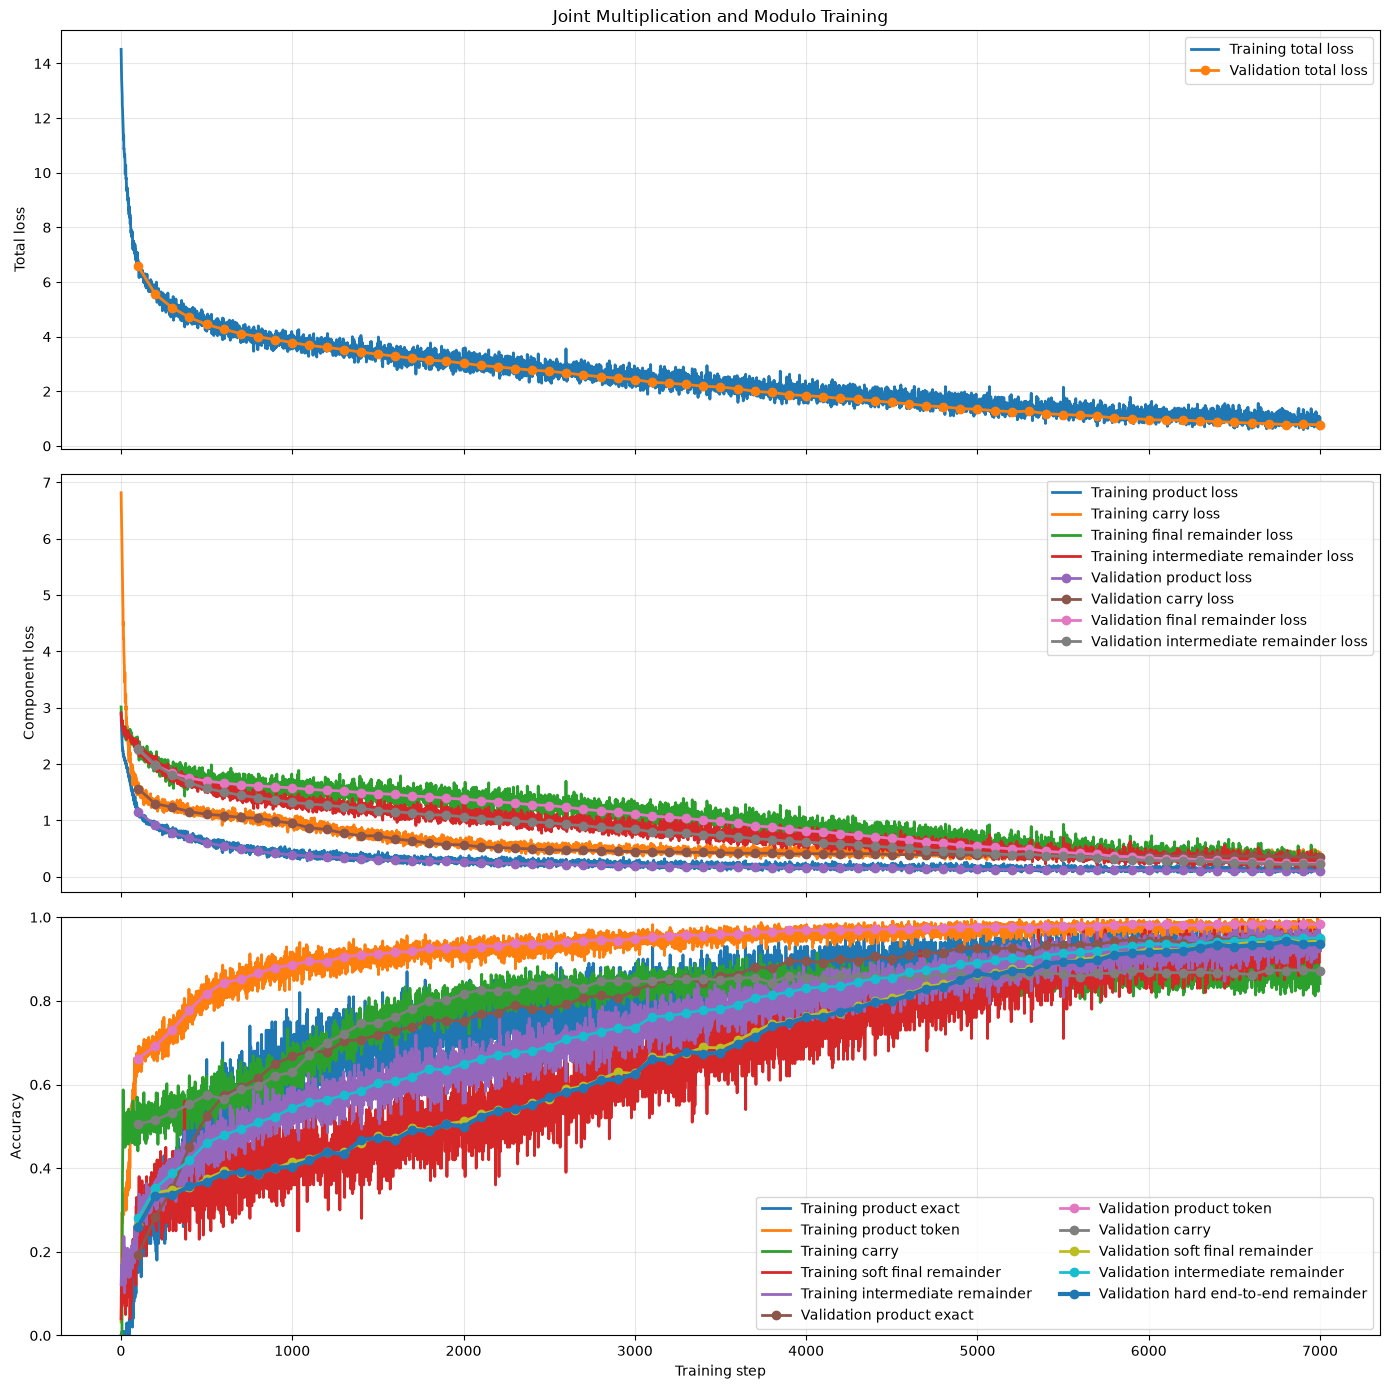

Training combined model:   0%|          | 0/1000 [00:00<?, ?it/s]

In [20]:
train_model(
    steps=1_000,
)